In [ ]:
#ai vs human content detection
# it is supervised alssifcation ai or human
#is to learn the pattern of the
#tesx

In [50]:
import re
import string
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

DATA_PATH = "/content/ai_human_detection_v1.csv"



In [45]:
df_raw = pd.read_csv(DATA_PATH)

print("=== Shape ===", df_raw.shape)
print("\n=== Missing values (count) ===")
print(df_raw.isna().sum().sort_values(ascending=False))

print("\n=== Duplicate rows ===", df_raw.duplicated().sum())

print("\n=== Label counts ===")
print(df_raw["human_or_ai"].value_counts(dropna=False))

# Garbage/error text rows
error_mask = df_raw["text"].astype(str).str.startswith("Error:") | df_raw["text"].astype(str).str.contains("Client Error", na=False)
print("\n=== Error-like rows in text ===", int(error_mask.sum()))
if error_mask.sum() > 0:
    print("\nSample error rows:")
    print(df_raw.loc[error_mask, ["text", "human_or_ai"]].head(3))

print("\n=== Data quality issues summary ===")
issues = []
if df_raw.isna().sum().max() > 0:
    issues.append("Missing values exist (mainly in 'prompt').")
if df_raw.duplicated().sum() > 0:
    issues.append("Duplicate rows exist.")
if error_mask.sum() > 0:
    issues.append("Garbage/error text rows exist (API Client Error messages).")
issues.append("Class imbalance exists (see label counts).")
print("- " + "\n- ".join(issues))

=== Shape === (686, 11)

=== Missing values (count) ===
prompt             181
text                 0
id                   0
human_or_ai          0
source_model         0
domain               0
language             0
edit_level           0
word_count           0
generation_date      0
version              0
dtype: int64

=== Duplicate rows === 0

=== Label counts ===
human_or_ai
ai                335
human             181
post_edited_ai    170
Name: count, dtype: int64

=== Error-like rows in text === 6

Sample error rows:
                                                 text     human_or_ai
1   Error: 400 Client Error: Bad Request for url: ...              ai
2   Error: 404 Client Error: Not Found for url: ht...              ai
20  Error: 400 Client Error: Bad Request for url: ...  post_edited_ai

=== Data quality issues summary ===
- Missing values exist (mainly in 'prompt').
- Garbage/error text rows exist (API Client Error messages).
- Class imbalance exists (see label counts).


In [51]:
# =========================
# Task 2: Missing Value Strategy
# =========================
print("Missing 'prompt' BEFORE:", df_raw["prompt"].isna().sum())

# Strategy: fill missing prompt with a constant category to keep all rows
df_raw["prompt"] = df_raw["prompt"].fillna("Unknown")

print("Missing 'prompt' AFTER :", df_raw["prompt"].isna().sum())
print("\nTop prompt values:")
print(df_raw["prompt"].value_counts().head(5))

Missing 'prompt' BEFORE: 181
Missing 'prompt' AFTER : 0

Top prompt values:
prompt
Unknown                                                                           181
Write product description for innovative tech gadget                               15
Write a news article about recent developments in renewable energy                 12
Write a professional job application email for software engineer position          10
Explain the concept of photosynthesis in simple terms for high school students     10
Name: count, dtype: int64


In [46]:
VALID_LABELS = {"human", "ai", "post_edited_ai"}

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["text"] = df["text"].astype(str)

    # Remove error rows
    error_mask = df["text"].str.startswith("Error:", na=False) | df["text"].str.contains("Client Error", na=False)
    df = df[~error_mask].copy()

    # Remove empty/very short
    df = df[df["text"].str.strip().str.len() >= 10].copy()

    # Keep only valid labels
    df = df[df["human_or_ai"].isin(VALID_LABELS)].copy()

    # Drop duplicates
    df = df.drop_duplicates()

    return df

df = clean_dataset(df_raw)

print("Rows before:", len(df_raw))
print("Rows after :", len(df))
print("\nCleaned label counts:")
print(df["human_or_ai"].value_counts())

Rows before: 686
Rows after : 680

Cleaned label counts:
human_or_ai
ai                333
human             181
post_edited_ai    166
Name: count, dtype: int64


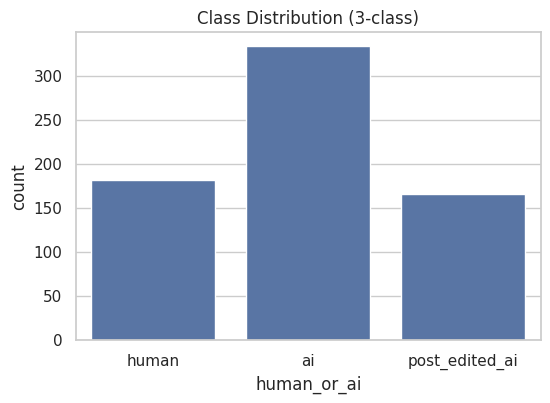

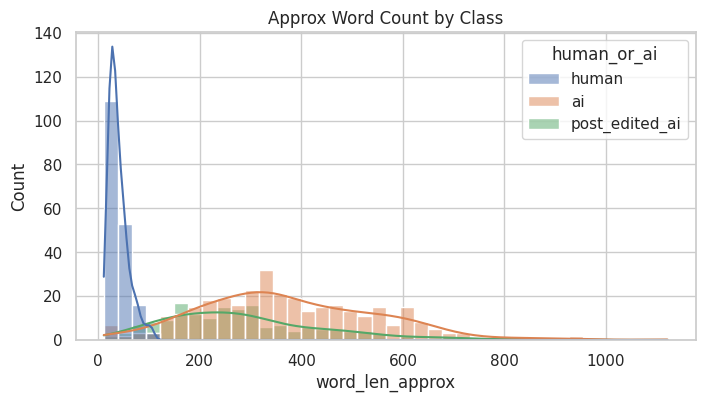

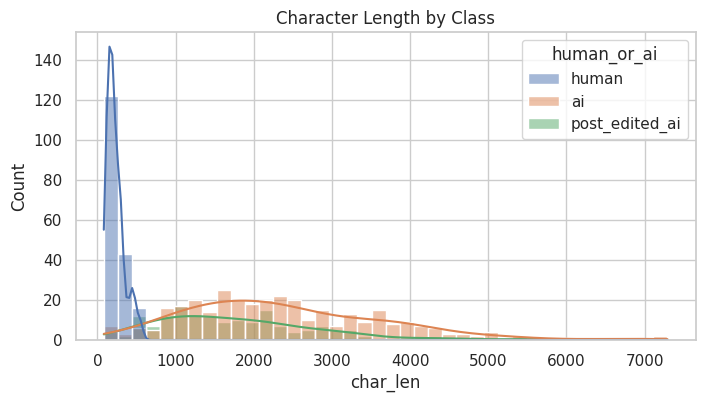

In [47]:
df_eda = df.copy()
df_eda["char_len"] = df_eda["text"].str.len()
df_eda["word_len_approx"] = df_eda["text"].str.split().apply(len)

plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x="human_or_ai")
plt.title("Class Distribution (3-class)")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df_eda, x="word_len_approx", hue="human_or_ai", bins=40, kde=True)
plt.title("Approx Word Count by Class")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df_eda, x="char_len", hue="human_or_ai", bins=40, kde=True)
plt.title("Character Length by Class")
plt.show()

In [19]:
# new data
#print(data_clean['target'].value_counts())

target
1    499
0    181
Name: count, dtype: int64


Train label distribution:
 human_or_ai
ai                266
human             145
post_edited_ai    133
Name: count, dtype: int64 

Test label distribution:
 human_or_ai
ai                67
human             36
post_edited_ai    33
Name: count, dtype: int64 


Accuracy: 0.7352941176470589

=== Classification Report (3-class) ===
                precision    recall  f1-score   support

            ai      0.700     0.836     0.762        67
         human      0.971     0.944     0.958        36
post_edited_ai      0.476     0.303     0.370        33

      accuracy                          0.735       136
     macro avg      0.716     0.694     0.697       136
  weighted avg      0.718     0.735     0.719       136



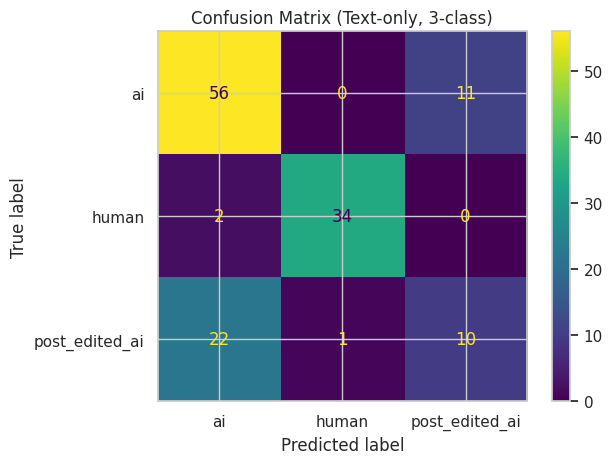

In [43]:
# =========================
# Model: Text-only baseline (3-class)
# =========================

# Optional: if you want missing value strategy applied for the assignment
df_raw["prompt"] = df_raw["prompt"].fillna("Unknown")

# Sort by time (optional)
df_model = df.copy()
df_model["generation_date"] = pd.to_datetime(df_model["generation_date"], errors="coerce")
df_model = df_model.sort_values(by="generation_date")

X = df_model["text"]
y = df_model["human_or_ai"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train label distribution:\n", y_train.value_counts(), "\n")
print("Test label distribution:\n", y_test.value_counts(), "\n")

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode"
    )),
    ("clf", LinearSVC(class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, pred))
print("\n=== Classification Report (3-class) ===")
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Text-only, 3-class)")
plt.show()

# New Section

In [23]:
data_clean['generation_date'] = pd.to_datetime(data_clean['generation_date'], errors='coerce')
data_sorted = data_clean.sort_values(by='generation_date')

In [24]:
def analyze_text_structure(text):
    if not isinstance(text, str): return pd.Series([0, 0, 0, 0, 0, 0])
    # 1 Word & Sentence Tokens
    words = text.split()
    sentences = text.replace('!', '.').replace('?', '.').split('.')
    sentences = [s for s in sentences if len(s) > 1] # ignore empty splits

    # 2 Length Features
    word_count = len(words)
    sentence_count = len(sentences)
    avg_word_len = np.mean([len(w) for w in words]) if word_count > 0 else 0
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0

    # 3 Diversity Feature (Unique words / Total words)
    lexical_diversity = len(set(words)) / word_count if word_count > 0 else 0

    # 4 Puncuation Load
    punct_count = sum([1 for char in text if char in string.punctuation])

    return pd.Series([word_count, avg_word_len, sentence_count, avg_sentence_len, lexical_diversity, punct_count])

In [25]:
# new columns
features = ['word_count', 'avg_word_length', 'sentence_count', 'avg_sentence_length', 'lexical_diversity', 'punctuation_count']
data_sorted[features] = data_sorted['text'].apply(analyze_text_structure)

print("Feature Engineering Complete. New columns added.")

Feature Engineering Complete. New columns added.


In [28]:
#style
sns.set(style="whitegrid")

In [29]:
print(data_sorted)

                                       id  \
464  37f2d53f-db85-4e1a-a3b1-d6f8c859b8cb   
170  d0f4309e-6575-4ec5-a72a-d02180ff578e   
80   4e1bd780-0c03-45ed-9e29-2855794c9858   
31   22e55139-c43d-479b-80fd-5d3189abbf11   
184  78acb622-4886-48fa-bb0d-9c900884611e   
..                                    ...   
298  31c60704-9444-4f44-829d-882669022c63   
632  e4ce89e4-7a11-49de-b8e7-3e351539e1c4   
431  3b30498b-56d4-4fe2-b86a-730a1c57a76e   
423  14612004-45b2-4018-b7d4-dda1ac79e8c9   
531  1137fe49-82f4-4d18-9161-a0c888ef3489   

                                                  text     human_or_ai  \
464  tech companies continue to invest heavily in a...           human   
170  setting up a rest api in python is actually pr...           human   
80   Climate change is really affecting our planet ...           human   
31   Dear Hiring Manager\n\nI am writing to apply f...           human   
184  Tech companies continue to invest heavily in a...           human   
..             

In [30]:
data_sorted.to_csv(r"/content/ai or human (2).csv", index=False)

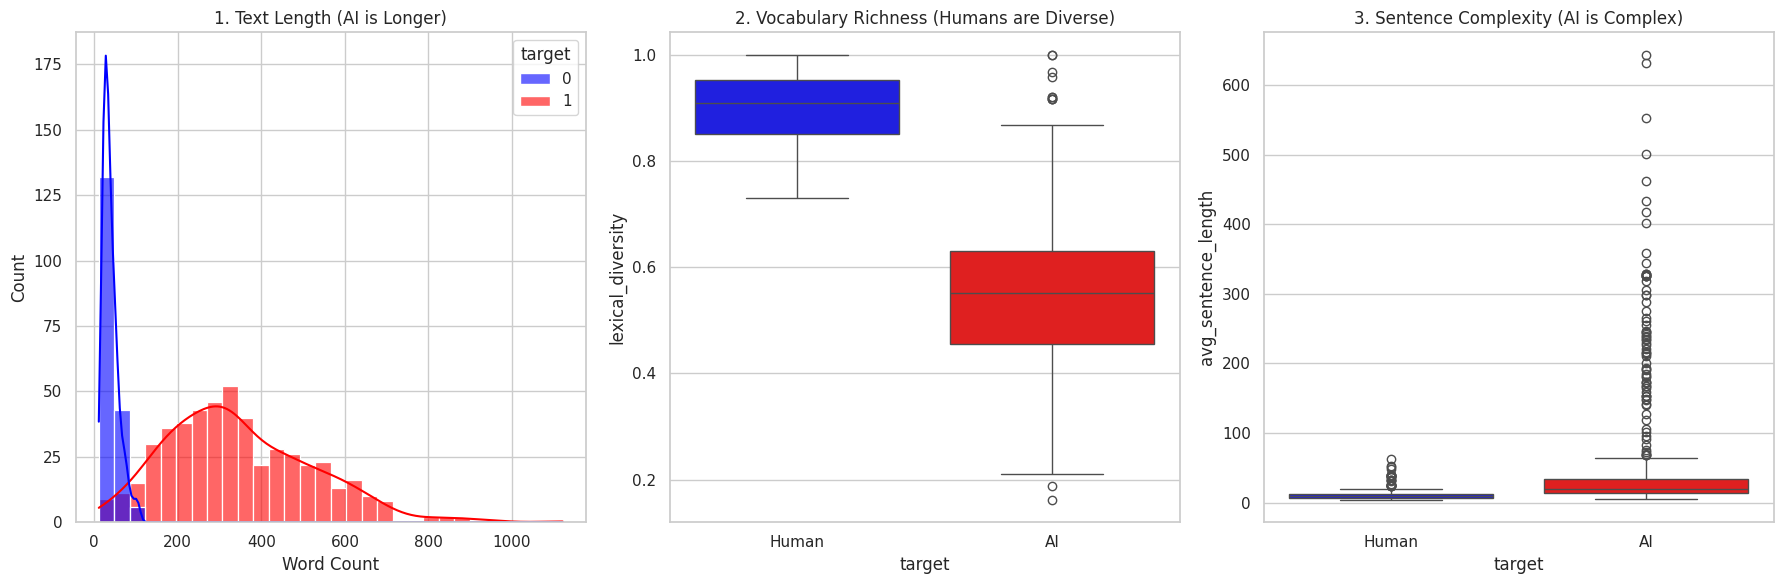

In [31]:



#  3 subplots (axes) side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2. Define Colors (Blue for Human, Red for AI)
colors = {0: "blue", 1: "red"}

# --- Plot 1: Word Count ---
sns.histplot(data=data_sorted, x='word_count', hue='target', kde=True,
             palette=colors, bins=30, ax=axes[0], alpha=0.6)
axes[0].set_title("1. Text Length (AI is Longer)")
axes[0].set_xlabel("Word Count")

# --- Plot 2: Lexical Diversity ---
sns.boxplot(data=data_sorted, x='target', y='lexical_diversity',
            palette=colors, hue='target', legend=False, ax=axes[1])
axes[1].set_title("2. Vocabulary Richness (Humans are Diverse)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Human', 'AI'])

# --- Plot 3: Sentence Length ---
sns.boxplot(data=data_sorted, x='target', y='avg_sentence_length',
            palette=colors, hue='target', legend=False, ax=axes[2])
axes[2].set_title("3. Sentence Complexity (AI is Complex)")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Human', 'AI'])

# 3. Show the final image
plt.tight_layout()
plt.show()

In [52]:
# Remove garbage rows before numeric analysis
df = df[~error_mask].copy()
df = df.dropna(subset=["text", "human_or_ai"]).copy()

print("Rows after removing error rows:", len(df))

def extract_text_numeric_features(text: str) -> pd.Series:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series({
            "char_len": 0,
            "word_len": 0,
            "sentence_count": 0,
            "avg_word_len": 0.0,
            "punct_count": 0,
            "lexical_diversity": 0.0
        })

    t = text.strip()
    words = t.split()
    word_len = len(words)
    avg_word_len = float(np.mean([len(w) for w in words])) if word_len > 0 else 0.0

    # sentence heuristic
    sentences = re.split(r"[.!?]+", t)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    sentence_count = len(sentences)

    punct_count = sum(1 for ch in t if ch in string.punctuation)
    lexical_div = (len(set(words)) / word_len) if word_len > 0 else 0.0

    return pd.Series({
        "char_len": len(t),
        "word_len": word_len,
        "sentence_count": sentence_count,
        "avg_word_len": avg_word_len,
        "punct_count": punct_count,
        "lexical_diversity": lexical_div
    })

num_features = ["char_len", "word_len", "sentence_count", "avg_word_len", "punct_count", "lexical_diversity"]
df[num_features] = df["text"].apply(extract_text_numeric_features)

print(df[num_features].head())
print("\nSummary:")
print(df[num_features].describe())

/tmp/ipykernel_738/2365728907.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~error_mask].copy()


Rows after removing error rows: 680
   char_len  word_len  sentence_count  avg_word_len  punct_count  \
0     208.0      34.0             5.0      5.147059          5.0   
3    4219.0     558.0            37.0      6.523297        137.0   
4     810.0     147.0            15.0      4.496599         21.0   
5     316.0      57.0             5.0      4.526316          4.0   
6     134.0      24.0             1.0      4.625000          0.0   

   lexical_diversity  
0           0.823529  
3           0.560932  
4           0.591837  
5           0.859649  
6           0.958333  

Summary:
          char_len     word_len  sentence_count  avg_word_len  punct_count  \
count   680.000000   680.000000      680.000000    680.000000   680.000000   
mean   1668.914706   264.520588       15.127941      5.090721    88.494118   
std    1375.829208   203.029332       15.691516      0.807369   113.750651   
min      81.000000    11.000000        1.000000      3.303030     0.000000   
25%     356.00000

In [53]:
# =========================
# =========================

df_num = df.copy()  # keep your cleaned df safe

def extract_text_numeric_features(text: str) -> pd.Series:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series({
            "char_len": 0,
            "word_len": 0,
            "sentence_count": 0,
            "avg_word_len": 0.0,
            "punct_count": 0,
            "lexical_diversity": 0.0
        })

    t = text.strip()
    words = t.split()
    word_len = len(words)
    avg_word_len = float(np.mean([len(w) for w in words])) if word_len > 0 else 0.0

    sentences = re.split(r"[.!?]+", t)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    sentence_count = len(sentences)

    punct_count = sum(1 for ch in t if ch in string.punctuation)
    lexical_div = (len(set(words)) / word_len) if word_len > 0 else 0.0

    return pd.Series({
        "char_len": len(t),
        "word_len": word_len,
        "sentence_count": sentence_count,
        "avg_word_len": avg_word_len,
        "punct_count": punct_count,
        "lexical_diversity": lexical_div
    })

num_features = ["char_len", "word_len", "sentence_count", "avg_word_len", "punct_count", "lexical_diversity"]
df_num[num_features] = df_num["text"].apply(extract_text_numeric_features)

print("Numeric feature preview:")
print(df_num[num_features].head())
print("\nSummary stats:")
print(df_num[num_features].describe())

Numeric feature preview:
   char_len  word_len  sentence_count  avg_word_len  punct_count  \
0     208.0      34.0             5.0      5.147059          5.0   
3    4219.0     558.0            37.0      6.523297        137.0   
4     810.0     147.0            15.0      4.496599         21.0   
5     316.0      57.0             5.0      4.526316          4.0   
6     134.0      24.0             1.0      4.625000          0.0   

   lexical_diversity  
0           0.823529  
3           0.560932  
4           0.591837  
5           0.859649  
6           0.958333  

Summary stats:
          char_len     word_len  sentence_count  avg_word_len  punct_count  \
count   680.000000   680.000000      680.000000    680.000000   680.000000   
mean   1668.914706   264.520588       15.127941      5.090721    88.494118   
std    1375.829208   203.029332       15.691516      0.807369   113.750651   
min      81.000000    11.000000        1.000000      3.303030     0.000000   
25%     356.000000    

=== IQR Outlier Report ===
char_len           outliers=   7 | bounds=(-2813.88, 5639.12)
word_len           outliers=   3 | bounds=(-441.88, 899.12)
sentence_count     outliers=  33 | bounds=(-23.00, 49.00)
avg_word_len       outliers=   0 | bounds=(2.60, 7.55)
punct_count        outliers=  30 | bounds=(-160.00, 288.00)
lexical_diversity  outliers=   0 | bounds=(-0.01, 1.32)


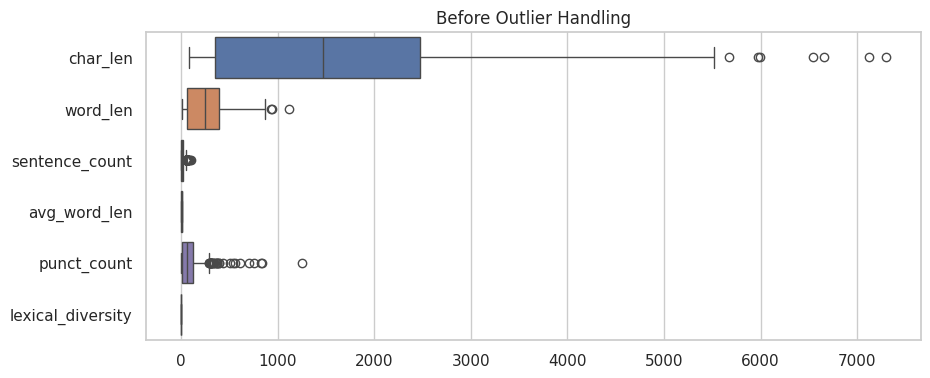

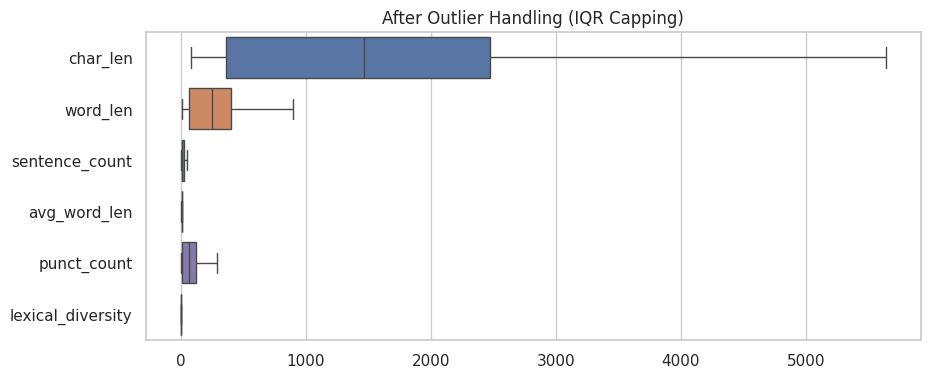

In [54]:
# =========================
# Task 3: Outliers using IQR (detect + cap)
# =========================

def iqr_bounds(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return float(lower), float(upper)

print("=== IQR Outlier Report ===")
bounds = {}
for col in num_features:
    lower, upper = iqr_bounds(df_num[col])
    outliers = ((df_num[col] < lower) | (df_num[col] > upper)).sum()
    bounds[col] = (lower, upper)
    print(f"{col:18s} outliers={int(outliers):4d} | bounds=({lower:.2f}, {upper:.2f})")

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_num[num_features], orient="h")
plt.title("Before Outlier Handling")
plt.show()

df_capped = df_num.copy()
for col in num_features:
    lower, upper = bounds[col]
    df_capped[col] = df_capped[col].clip(lower, upper)

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_capped[num_features], orient="h")
plt.title("After Outlier Handling (IQR Capping)")
plt.show()

=== Min-Max sanity (min ~ 0, max ~ 1) ===
     char_len_minmax  word_len_minmax  sentence_count_minmax  \
min              0.0              0.0                    0.0   
max              1.0              1.0                    1.0   

     avg_word_len_minmax  punct_count_minmax  lexical_diversity_minmax  
min                  0.0                 0.0                       0.0  
max                  1.0                 1.0                       1.0  

=== Z-score sanity (mean ~ 0, std ~ 1) ===
        char_len_z    word_len_z  sentence_count_z  avg_word_len_z  \
mean -6.269495e-17 -1.044916e-16     -5.224579e-17   -7.836868e-17   
std   1.000736e+00  1.000736e+00      1.000736e+00    1.000736e+00   

      punct_count_z  lexical_diversity_z  
mean  -2.089832e-17         3.134747e-16  
std    1.000736e+00         1.000736e+00  


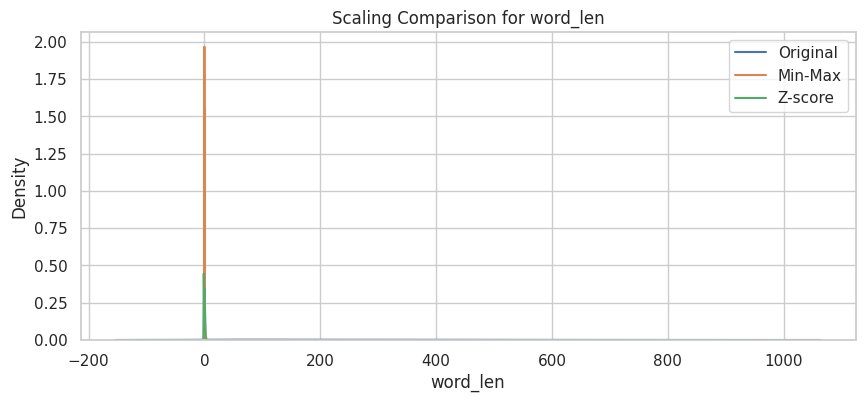

In [55]:
# =========================
# Task 4: Normalize using Min-Max and Z-score
# =========================

X_num = df_capped[num_features].copy()

# Min-Max
mm = MinMaxScaler()
X_minmax = mm.fit_transform(X_num)
df_minmax = pd.DataFrame(X_minmax, columns=[f"{c}_minmax" for c in num_features])

print("=== Min-Max sanity (min ~ 0, max ~ 1) ===")
print(df_minmax.describe().loc[["min", "max"]])

# Z-score
zs = StandardScaler()
X_z = zs.fit_transform(X_num)
df_z = pd.DataFrame(X_z, columns=[f"{c}_z" for c in num_features])

print("\n=== Z-score sanity (mean ~ 0, std ~ 1) ===")
print(df_z.describe().loc[["mean", "std"]])

# Visual check
feat = "word_len"
plt.figure(figsize=(10, 4))
sns.kdeplot(X_num[feat], label="Original")
sns.kdeplot(df_minmax[f"{feat}_minmax"], label="Min-Max")
sns.kdeplot(df_z[f"{feat}_z"], label="Z-score")
plt.title(f"Scaling Comparison for {feat}")
plt.legend()
plt.show()

=== Explained variance ratio ===
PC1: 0.7228
PC2: 0.1939
PC3: 0.0393
PC4: 0.0253
PC5: 0.0178
PC6: 0.0009


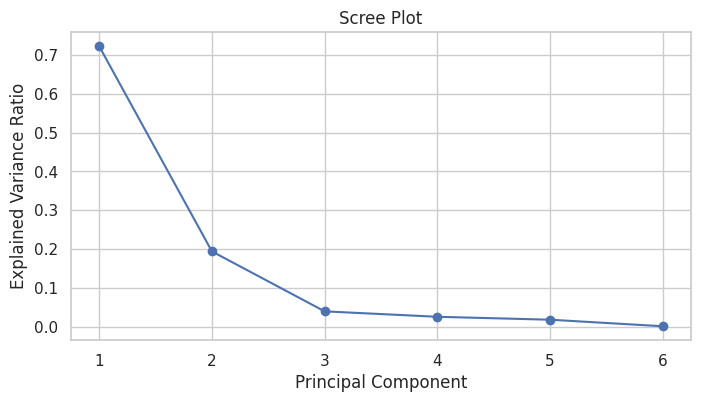

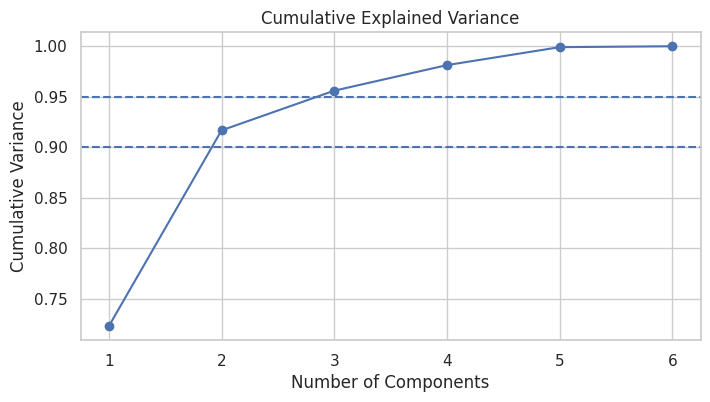

Components for 90% variance: 2
Components for 95% variance: 3

Top contributors to PC1:
char_len             0.472065
word_len             0.458022
punct_count          0.447891
sentence_count       0.426107
lexical_diversity    0.356430
avg_word_len         0.241151
Name: PC1, dtype: float64

Top contributors to PC2:
avg_word_len         0.756011
lexical_diversity    0.557209
sentence_count       0.241183
word_len             0.220106
punct_count          0.090778
char_len             0.055760
Name: PC2, dtype: float64


In [56]:
# =========================
# Task 5: PCA + Explained Variance
# =========================

X_for_pca = X_z  # PCA works best on standardized features
pca = PCA()
X_pca = pca.fit_transform(X_for_pca)

explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

print("=== Explained variance ratio ===")
for i, v in enumerate(explained, start=1):
    print(f"PC{i}: {v:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.show()

k90 = int(np.argmax(cum >= 0.90) + 1)
k95 = int(np.argmax(cum >= 0.95) + 1)
print(f"Components for 90% variance: {k90}")
print(f"Components for 95% variance: {k95}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=num_features,
    columns=[f"PC{i+1}" for i in range(len(num_features))]
)

print("\nTop contributors to PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(6))

print("\nTop contributors to PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(6))